# Titanic — Survival Prediction

Predicting which passengers survived the sinking of the RMS Titanic (15 April 1912), using the Kaggle competition dataset.

- **Train set:** 891 passengers, labelled
- **Test set:** 418 passengers, unlabelled
- **Task:** binary classification — `Survived` ∈ {0, 1}
- **Base rate:** ~38% of passengers in the train set survived

---

## The Features

### `Survived` — target
0 = died, 1 = survived.

### `Pclass` — ticket class (1, 2, 3)
Proxy for socio-economic status, but also for *physical location on the ship*. Third-class cabins sat lower and further from the boat deck. Is expected to be one of the strongest predictors.

### `Sex`
Almost certainly the single strongest predictor. The evacuation followed a "women and children first" protocol, so I expect a large gap between male and female survival — and I expect most of the interesting modelling work to be about *where that protocol broke down*.

### `Age` — ~20% missing
Children were prioritised, so young passengers should survive at a higher rate. The missingness is a problem: with a fifth of the column gone, and the gaps likely concentrated in third class, imputing with a single global median would be misleading. `Name` can help here (see below). Whether a value is missing at all may itself be informative.

### `SibSp` — siblings + spouse aboard
### `Parch` — parents + children aboard
Both count relatives **on the ship**, not total family. Summed together (+1 for the passenger) they give family size. I don't expect a simple linear effect: travelling alone and travelling in a very large group may both be disadvantages, for different reasons.

### `Fare`
Price paid for the **whole ticket**, not per person — a family sharing one ticket shows the same total on every row. It also contains zeros, which are probably employees or guests rather than missing data. Fare should carry information that `Pclass` alone flattens: the difference between a cheap and an expensive first-class cabin.

### `Cabin` — ~77% missing
The intuition is that having a recorded cabin implies money implies a better chance. The catch is that cabins were mostly recorded *for first class*, so this may be little more than a restatement of `Pclass`. Worth checking rather than assuming. The leading letter is the deck, which is a more genuinely spatial piece of information.

### `Embarked` — port of boarding
`S` Southampton, `C` Cherbourg, `Q` Queenstown. Any survival differences between ports are probably explained by the class mix boarding at each. I'd treat an apparent `Embarked` effect as a confound until shown otherwise.

### `Name`
Not usable directly, but it contains an honorific. **Master** means a boy under roughly 13 — the most reliable age signal in the dataset, and one that survives the missingness in `Age`.

### `Ticket`
Looks like an identifier, but tickets were **shared between people travelling together** — families, but also friends, servants, and employers. Group size derived from the ticket captures relationships that `SibSp` and `Parch` cannot.

### `PassengerId`
A sequential row index. Carries no information.

---

## What I Expect to Find

1. `Sex` dominates, and a "predict all women survive" rule sets a surprisingly high baseline that any model has to beat.
2. `Pclass` and `Sex` interact — I expect the "women and children first" protocol to have been applied much more effectively in first class than in third.
3. The child effect will show up more clearly in the `Master` title than in the `Age` column.
4. `Cabin` will turn out to be largely redundant with `Pclass`.
5. Family size will have a non-linear relationship with survival.

The point of the EDA below is to test these, and to write down which ones turn out to be wrong.

In [2416]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, GridSearchCV, learning_curve

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import ConfusionMatrixDisplay

In [2417]:
train_df = pd.read_csv("data/train.csv")

test_df = pd.read_csv("data/test.csv")

In [2418]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [2419]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2420]:
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [2421]:
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(train_df[col].value_counts(dropna=False), '\n')

Survived
0    549
1    342
Name: count, dtype: int64 

Pclass
3    491
1    216
2    184
Name: count, dtype: int64 

Sex
male      577
female    314
Name: count, dtype: int64 

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64 



In [2422]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [2423]:
print(train_df['PassengerId'].is_unique)   
print(train_df.duplicated().sum())

True
0


In [2424]:
train_df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
Sex,,,
female,233,314,0.742038
male,109,577,0.188908


In [2425]:
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=range(0, 90, 10))

train_df.groupby('AgeGroup', observed=True)['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
AgeGroup,,,
"(0, 10]",38,64,0.593750
"(10, 20]",44,115,0.382609
"(20, 30]",84,230,0.365217
"(30, 40]",69,155,0.445161
"(40, 50]",33,86,0.383721
"(50, 60]",17,42,0.404762
"(60, 70]",4,17,0.235294
"(70, 80]",1,5,0.200000


In [2426]:
train_df.groupby(['Sex', 'AgeGroup'], observed=True)['Survived'].agg(['sum', 'count', 'mean'])

sum  count      mean
Sex    AgeGroup                      
female (0, 10]    19     31  0.612903
       (10, 20]   34     46  0.739130
       (20, 30]   61     81  0.753086
       (30, 40]   46     55  0.836364
       (40, 50]   21     31  0.677419
       (50, 60]   13     14  0.928571
       (60, 70]    3      3  1.000000
male   (0, 10]    19     33  0.575758
       (10, 20]   10     69  0.144928
       (20, 30]   23    149  0.154362
       (30, 40]   23    100  0.230000
       (40, 50]   12     55  0.218182
       (50, 60]    4     28  0.142857
       (60, 70]    1     14  0.071429
       (70, 80]    1      5  0.200000

In [2427]:
train_df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])

,sum,count,mean
Pclass,,,
1,136,216,0.629630
2,87,184,0.472826
3,119,491,0.242363


In [2428]:
train_df.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'mean']).unstack()

count                mean                    
Pclass     1    2    3         1         2         3
Sex                                                 
female    94   76  144  0.968085  0.921053  0.500000
male     122  108  347  0.368852  0.157407  0.135447

In [2429]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df.groupby('FamilySize')['Survived'].agg(['count', 'mean'])

,count,mean
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [2430]:
train_df.groupby('Embarked')['Survived'].agg(['count', 'mean'])

,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


In [2431]:
pd.crosstab(train_df['Embarked'], train_df['Pclass'], normalize='index')

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [2432]:
pd.crosstab(train_df['Cabin'].notna(), train_df['Pclass'], normalize='columns')

Pclass,1,2,3
Cabin,,,
False,0.185185,0.913043,0.97556
True,0.814815,0.086957,0.02444


In [2433]:
train_df['Title'] = train_df['Name'].str.extract(r',\s*([^\.]+)\.')
train_df.groupby('Title')['Survived'].agg(['sum', 'count', 'mean']).sort_values('count', ascending=False)

,sum,count,mean
Title,,,
Mr,81,517,0.156673
Miss,127,182,0.697802
Mrs,99,125,0.792000
Master,23,40,0.575000
Dr,3,7,0.428571
Rev,0,6,0.000000
Major,1,2,0.500000
Col,1,2,0.500000
Mlle,2,2,1.000000


In [2434]:
train_df['Ticket'].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

In [2435]:
train_df[train_df['Fare'] == 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FamilySize,Title
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,"(30.0, 40.0]",1,Mr
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,"(30.0, 40.0]",1,Mr
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,"(20.0, 30.0]",1,Mr
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,"(10.0, 20.0]",1,Mr
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Mr
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,NaN,1,Mr
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,"(40.0, 50.0]",1,Mr
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,NaN,1,Mr


<Axes: >

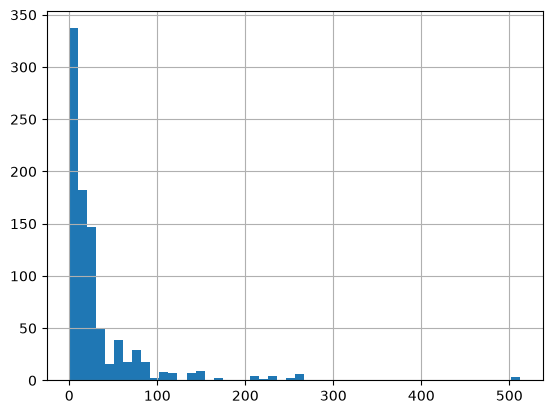

In [2436]:
train_df['Fare'].hist(bins=50)

---

## What the Data Showed

| # | Hypothesis | Verdict | Evidence |
|---|---|---|---|
| 1 | `Sex` dominates | Confirmed | 74.2% female vs 18.9% male |
| 2 | `Sex × Pclass` interaction | Confirmed | Female survival: 96.8% → 92.1% → **50.0%** |
| 3 | `Master` beats `Age` as child signal | Partly | See below |
| 4 | `Cabin` redundant with `Pclass` | Confirmed | 81.5% of 1st class have a cabin; 2.4% of 3rd |
| 5 | Family size non-linear | Confirmed | 30% alone → 72% at size 4 → 0% at size 8+ |
| 6 | `Embarked` is a confound | Confirmed | 50.6% of Cherbourg passengers were 1st class |

### 1 & 2 — Sex, and where the protocol broke down

The `Sex × Pclass` table is the dataset in six numbers. Female survival barely moves between 1st and 2nd class (96.8% → 92.1%), then falls off a cliff in 3rd (50.0%). Male survival is low everywhere and its class gradient is much shallower (36.9% → 15.7% → 13.5%).

So "women and children first" was real, but it was a *first- and second-class* protocol. A third-class woman had roughly the same chance as a first-class man. Any model that treats `Sex` and `Pclass` as independent additive effects will get this wrong.

Baseline to beat: predicting "all women survive, all men die" gets **78.7%** accuracy on the train set. That is the number every model must clear.

### 3 — The child signal is weaker than expected

Raw `Age` shows the effect: the 0–10 bin survives at 59.4% against a 38.4% base rate, and it is the only bin materially above it. Everything from 10 to 60 sits flat around 0.37–0.45. Age does almost nothing except identify children.

But **the hypothesis was too strong.** `Master` survives at 57.5% (n=40) — far above `Mr` at 15.7%, so it clearly recovers the child effect. Yet boys aged 0–10 in the raw `Age` column survive at 57.6% (n=33), which is essentially identical. `Master` is not *better* than `Age` here; it is **equally good and available for the ~20% of rows where `Age` is missing.** That is the real argument for using it — coverage, not accuracy.

The finding that does hold: `Title` is the right variable to *impute* `Age` from, because it partitions the population by age and marital status simultaneously.

### 4 — Cabin is Pclass in disguise

81.5% of first-class passengers have a recorded cabin; 8.7% of second and 2.4% of third do. `HasCabin` is close to an indicator for `Pclass == 1` and should not be presented as independent evidence of anything. The **deck letter** may still carry spatial information, but with 687 missing values it will be thin.

The correct interpretation is that this is a *record-keeping* artefact, not a fact about the ship. Everyone had somewhere to sleep. Only first class had it written down.

### 5 — Family size is a hump, not a line

| FamilySize | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 11 |
|---|---|---|---|---|---|---|---|---|---|
| survival | 0.30 | 0.55 | 0.58 | 0.72 | 0.20 | 0.14 | 0.33 | 0.00 | 0.00 |
| n | 537 | 161 | 102 | 29 | 15 | 22 | 12 | 6 | 7 |

Rises to a peak at 4, then collapses. Encoding this as a single continuous variable would force a linear model to average the two halves into nothing. Bin it: `Alone` (1), `Small` (2–4), `Large` (5+).

Caveat: the tail cells are tiny. FamilySize 8 has n=6 and FamilySize 11 has n=7 — the 0.00 survival rates there are six and seven people, not a law of nature. The `Large` bin as a whole (n=62, ~16% survival) is the defensible claim.

### 6 — Embarked explains nothing on its own

Cherbourg's higher survival rate (55.4% vs Southampton's 33.7%) is not about the port. Half of Cherbourg's passengers boarded in first class; 93.5% of Queenstown's boarded in third. `Embarked` is measuring `Pclass` through a proxy. If it shows up as important in a feature-importance plot later, that is a reason to be suspicious of the plot, not to believe the feature.

### Things I did not predict

**Fare has 15 zeros, all male, all boarded at Southampton.** Several share ticket `LINE` or consecutive ticket numbers (`239853`, `239854`). Among them is **Thomas Andrews Jr** — the ship's designer, who died. These are employees of the White Star Line and its suppliers, travelling on company business, not passengers who happened to pay nothing. 14 of 15 died. This is a real category, and `Fare == 0` deserves its own flag rather than being imputed away.

**`Fare` is a total, and the data proves it.** Ticket `347082` appears 7 times — the Andersson family, all with identical `Fare`. There are only 681 unique tickets across 891 rows, so roughly a quarter of passengers share a ticket with someone. Per-person fare requires dividing by group size, computed across train *and* test together, since families are split between the files.

**`Fare` is extremely right-skewed.** Median 14.45, max 512.33. Log-transform before feeding it to anything distance-based.

**Old age is dangerous, and it's not just class.** The 60–70 bin survives at 23.5% and 70–80 at 20.0%, both well below the base rate — despite older passengers skewing wealthier. Small samples (n=17, n=5), so hold this loosely.

**`Rev` went 0 for 6.** Every clergyman aboard died. Almost certainly not a causal feature; almost certainly a story.

### Decisions carried into preprocessing

- Extract `Title` from `Name`; map `Mlle`/`Ms` → `Miss`, `Mme` → `Mrs`, then fold every title outside the four common ones (`Mr`, `Mrs`, `Miss`, `Master`) into `Rare`. This is robust to unseen titles such as `Dona`, which appears only in the test set.
- Impute `Age` by median within `Title × Pclass`, **not** a global median.
- Add `AgeIsMissing` as a feature.
- Build `FamilySize`, then bin into `Alone` / `Small` / `Large`. Keep `IsAlone` separately.
- Log-transform `Fare` (`np.log1p`).
- Add `IsZeroFare` flag.
- Impute the 2 missing `Embarked` values. Both are 1st class, £80, cabin `B28`, sharing ticket `113572` — infer from comparable passengers rather than filling with the mode `S`.
- Drop `Cabin` as a direct feature; keep `HasCabin` only to demonstrate its redundancy, and test `Deck` separately.
- Drop `PassengerId`, `Name`, `Ticket` from the feature matrix once their derived features are extracted.
- Explicitly model the `Sex × Pclass` interaction for any linear model. Tree models will find it unaided.

### A note on where this is going

Nearly all the signal above lives in `Sex`, `Pclass`, and `Title`. The remaining features add refinement at the margin. A realistic ceiling on this dataset is around 0.80 on the leaderboard, against a 0.787 baseline from a single `if` statement — the gap is narrow, and most of the work from here is about not making it worse.

# Data Cleaning & Feature Engineering

In [2437]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup',
       'FamilySize', 'Title'],
      dtype='str')

In [2438]:
train = train_df.copy()
test = test_df.copy()

### Title

In [2439]:
test['Title'] = test['Name'].str.extract(r',\s*([^\.]+)\.')

print(train['Title'].value_counts(), '\n')
print(test['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64 

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


In [2440]:
for df in [train,test]:
    # normalise foreign-language equivalents
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    # everything that is not common becomes 'Rare'
    common = ['Mr', 'Miss', 'Mrs', 'Master']
    df['Title'] = df['Title'].where(df['Title'].isin(common), 'Rare') #keep the title where it is in common and replace the rest with Rare

In [2441]:
print(train['Title'].value_counts())
print("\n")
print(test['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64


### Age

In [2442]:
for df in [train, test]:
    df['AgeIsMissing'] = df['Age'].isna().astype(int)

age_medians = train.groupby(['Title', 'Pclass'])['Age'].median()
print(age_medians)

Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         32.0
        3         31.0
Rare    1         48.5
        2         46.5
Name: Age, dtype: float64


In [2443]:
for df in [train, test]:
    fill = df.set_index(['Title', 'Pclass']).index.map(age_medians)
    df['Age'] = df['Age'].fillna(pd.Series(fill, index=df.index))

In [2444]:
print(train['Age'].isna().sum())   
print(test['Age'].isna().sum())    

0
0


### Embarked

Notes: 

* could fill with mode but there is enough info so that I can a better job 
* median fare from 'C' is must closer than the median fare form both 'Q' and 'S'

In [2445]:
print(train['Embarked'].isna().sum())
print(test['Embarked'].isna().sum())

2
0


In [2446]:
print(train[train['Embarked'].isna()][['Title','Pclass', 'Fare', 'Cabin', 'Ticket']])
print("\n")
print(train[train['Pclass'] == 1].groupby('Embarked')['Fare'].median())

    Title  Pclass  Fare Cabin  Ticket
61   Miss       1  80.0   B28  113572
829   Mrs       1  80.0   B28  113572


Embarked
C    78.2667
Q    90.0000
S    52.0000
Name: Fare, dtype: float64


In [2447]:
train['Embarked'] = train['Embarked'].fillna('C')

### Fare

In [2448]:
print(train['Fare'].isna().sum())
print(test['Fare'].isna().sum())

0
1


In [2449]:
fare_medians = train.groupby(['Pclass'])['Fare'].median()
print(fare_medians)

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64


In [2450]:
for df in [train, test]:
    fill = df.set_index(['Pclass']).index.map(fare_medians)
    df['Fare'] = df['Fare'].fillna(pd.Series(fill, index=df.index))

In [2451]:
for df in [train, test]:
    df['IsZeroFare'] = (df['Fare'] == 0).astype(int)

In [2452]:
for df in [train, test]:
    df['FareLog'] = np.log1p(df['Fare'])

In [2453]:
print(test['Fare'].isna().sum())
print("\n")
print(train[["Name","IsZeroFare"]].loc[train["IsZeroFare"]==1])
print("\n")
print(train[['Fare', 'FareLog']].describe())

0


                                 Name  IsZeroFare
179               Leonard, Mr. Lionel           1
263             Harrison, Mr. William           1
271      Tornquist, Mr. William Henry           1
277       Parkes, Mr. Francis "Frank"           1
302   Johnson, Mr. William Cahoone Jr           1
413    Cunningham, Mr. Alfred Fleming           1
466             Campbell, Mr. William           1
481  Frost, Mr. Anthony Wood "Archie"           1
597               Johnson, Mr. Alfred           1
633     Parr, Mr. William Henry Marsh           1
674        Watson, Mr. Ennis Hastings           1
732              Knight, Mr. Robert J           1
806            Andrews, Mr. Thomas Jr           1
815                  Fry, Mr. Richard           1
822   Reuchlin, Jonkheer. John George           1


             Fare     FareLog
count  891.000000  891.000000
mean    32.204208    2.962246
std     49.693429    0.969048
min      0.000000    0.000000
25%      7.910400    2.187218
50%     14.454

### Family

In [2454]:
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

In [2455]:
for df in [train, test]:
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 20], labels=['Alone', 'Small', 'Large'])

In [2456]:
train.groupby('FamilyGroup', observed=True)['Survived'].agg(['count', 'mean'])

,count,mean
FamilyGroup,,
Alone,537,0.303538
Small,292,0.578767
Large,62,0.161290


### Cabin

In [2457]:
for df in [train, test]:
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df['Deck'] = df['Cabin'].str[0].fillna('M')

In [2458]:
train["Deck"]

0      M
1      C
2      M
3      C
4      M
      ..
886    M
887    B
888    M
889    C
890    M
Name: Deck, Length: 891, dtype: str

In [2459]:
print(train['Deck'].value_counts())
print(test['Deck'].value_counts())

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64
Deck
M    327
C     35
B     18
D     13
E      9
F      8
A      7
G      1
Name: count, dtype: int64


In [2460]:
for df in [train, test]:
    df['Deck'] = df['Deck'].replace('T', 'M')

### Drop of useless features

In [2461]:
test_ids = test['PassengerId'].copy()

drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

train = train.drop(columns='AgeGroup')

In [2462]:
print(train.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'Title', 'AgeIsMissing', 'IsZeroFare', 'FareLog', 'IsAlone', 'FamilyGroup', 'HasCabin', 'Deck']


In [2463]:
print(train.isna().sum())
print(test.isna().sum())
print("\n")
print(set(train.columns) - set(test.columns))   
print(set(test.columns) - set(train.columns))   

Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
FamilySize      0
Title           0
AgeIsMissing    0
IsZeroFare      0
FareLog         0
IsAlone         0
FamilyGroup     0
HasCabin        0
Deck            0
dtype: int64
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Title           0
AgeIsMissing    0
IsZeroFare      0
FareLog         0
FamilySize      0
IsAlone         0
FamilyGroup     0
HasCabin        0
Deck            0
dtype: int64


{'Survived'}
set()


### Summary

Every transformation below learns its parameters from **train only** and applies them to both frames, to avoid leaking test information into preprocessing.

| Column | Missing | What I did | Why |
|---|---|---|---|
| `Title` *(new)* | — | Extracted from `Name`; folded `Mlle`/`Ms`→`Miss`, `Mme`→`Mrs`; everything outside the four common titles → `Rare` | Honorific encodes age + sex + social role; robust to unseen titles like `Dona` |
| `Age` | 177 | Imputed with the median of each `Title × Pclass` group (from train) | A 1st-class `Mrs` and a 3rd-class `Miss` have very different ages; a global median erases that |
| `AgeIsMissing` *(new)* | — | Flag = 1 where `Age` was originally blank | Missingness isn't random — it correlates with class and survival |
| `Embarked` | 2 | Filled with `C` | Both missing rows are 1st class at £80; median 1st-class fare is closest to Cherbourg's |
| `Fare` | 1 (test) | Filled with the 3rd-class median | The one missing passenger is 3rd class; the overall median would overprice him |
| `IsZeroFare` *(new)* | — | Flag = 1 where `Fare == 0` | The 15 zero-fare men are White Star employees, a real category (14/15 died) |
| `FareLog` *(new)* | — | `log1p(Fare)` | Fare is extremely right-skewed (14 median vs 512 max); helps linear/distance models |
| `FamilySize` *(new)* | — | `SibSp + Parch + 1` | Combines the two relative-count columns |
| `IsAlone` *(new)* | — | Flag = 1 where `FamilySize == 1` | Solo travellers (mostly 3rd-class men) had low survival |
| `FamilyGroup` *(new)* | — | Binned into `Alone` / `Small` (2–4) / `Large` (5+) | Survival vs family size is a hump, not a line — binning lets the model use both halves |
| `HasCabin` *(new)* | — | Flag = 1 where `Cabin` recorded | Kept mainly to demonstrate its redundancy with `Pclass` |
| `Deck` *(new)* | — | First letter of `Cabin`, `M` for missing; `T`→`M` | Deck height/position is the one part of Cabin that isn't just a Pclass echo |
| `AgeGroup` | — | **Dropped** | An EDA-only column; leaked into the frame with 177 NaNs and was never a model feature |
| `PassengerId` | — | Dropped (test IDs saved separately) | Pure row index |
| `Name`, `Ticket`, `Cabin` | — | Dropped | Fully replaced by the derived features above |

**Deferred and deliberately skipped:** `FarePerPerson` and `TicketGroupSize`, which require joining ticket groups across train + test. Considered but judged low marginal value — `Pclass` and `FamilySize` already capture most of the same signal, and the added cross-frame complexity wasn't justified for a first pass. Documented here rather than omitted.

**Result:** no missing values in either frame; train and test share an identical feature set apart from `Survived`.

# Enconding

In [2464]:
cat_cols = ['Sex', 'Embarked', 'Title', 'FamilyGroup', 'Deck']

train = pd.get_dummies(train, columns=cat_cols, drop_first=False)
test  = pd.get_dummies(test,  columns=cat_cols, drop_first=False)

In [2465]:
y = train['Survived']
X = train.drop(columns='Survived')

test = test.reindex(columns=X.columns, fill_value=0)

In [2466]:
print(X.shape, test.shape)
print(list(X.columns) == list(test.columns))

(891, 32) (418, 32)
True


In [2467]:
boolean_cols = X.select_dtypes("bool").columns

X[boolean_cols] = X[boolean_cols].astype(int)
test[boolean_cols] = test[boolean_cols].astype(int)

In [2468]:
print(list(X.columns) == list(test.columns))

print(X.dtypes.value_counts())
print("\n")
print(X.shape, test.shape)

True
int64      29
float64     3
Name: count, dtype: int64


(891, 32) (418, 32)


Models operate on numbers, so the text categories had to be converted before any model could use them. The concern isn't just *making* them numeric — it's not inventing false structure while doing so.

**One-hot encoding** for `Sex`, `Embarked`, `Title`, `FamilyGroup`, `Deck`. Each becomes one 0/1 column per category. This avoids implying an order that doesn't exist: encoding ports as S=0, C=1, Q=2 would tell the model Q is "greater than" C, which is meaningless.

**Left as-is:** `Pclass` — already 1/2/3, and that order is real (1st > 2nd > 3rd). The engineered flags (`IsAlone`, `HasCabin`, `AgeIsMissing`, `IsZeroFare`) are already 0/1.

# Modeling

The workflow is: establish a baseline, compare several models with sensible defaults using cross-validation, tune the most promising ones, and submit the best to Kaggle for a final honest score.

**On validation and leakage.** Cross-validation here scores each model on folds it didn't train on, which removes the main form of leakage (a model being tested on rows it learned from). It does not fully remove a subtler one: some feature-engineering decisions — which titles to group, how to bin family size — were made after looking at survival patterns in the *whole* training set. That hindsight can't be undone by cross-validation, so the CV scores below are mildly optimistic.

This is handled deliberately rather than ignored. Cross-validation is used to *compare models against each other* (a fair comparison, since all models share the same features and folds). The **Kaggle test set** — 418 passengers whose labels were never seen — is the uncontaminated measure of real performance. The gap between CV and Kaggle scores reflects the hindsight above. Tuning is done with `GridSearchCV`, which cross-validates internally on the training set only and never touches the test set, so it doesn't reintroduce leakage.

### Baseline

In [2469]:
baseline_pred = X['Sex_female']

baseline_acc = (baseline_pred == y).mean()
print(round(baseline_acc,5))

0.78676


Before building any model, we establish a baseline: the simplest defensible prediction, which every real model must beat.

**The rule:** predict that every woman survives and every man dies. This follows directly from the EDA, where `Sex` was the strongest single predictor (74% of women survived vs 19% of men).

**Why compute it on the training set:** the rule involves no fitting — it has no parameters and never looks at the labels to decide what to do. So there's nothing to leak. We're not estimating how it generalizes; we're just describing how often this fixed rule is correct on the data we have. Crucially, it must be measured on the *same* data our models' cross-validation scores will come from, so the comparison is like-for-like.

(Note: on Kaggle's held-out test set this same rule scores ~0.765. That's a separate measurement on different passengers — used later as a final reality check, not as the bar for local model comparison.)

### Crossvalidation

In [2470]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Model comparisson

In [2471]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42), 
}

results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'CV Mean': scores.mean(), 'CV Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print(results_df.round(4))

                 Model  CV Mean  CV Std
0  Logistic Regression   0.8294  0.0147
1    Gradient Boosting   0.8294  0.0189
2        Random Forest   0.8137  0.0208


### Logostic regression 

In [2472]:
lr_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={'lr__C': [0.01, 0.1, 0.5, 1, 5, 10, 100]},
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
lr_grid.fit(X, y)
print("LR best params:", lr_grid.best_params_)
print(f"LR best CV:     {lr_grid.best_score_:.4f}")

LR best params: {'lr__C': 100}
LR best CV:     0.8339


### Gradient Boosting 

In [2473]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [1, 2, 3, 4]
    },
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
gb_grid.fit(X, y)
print("GB  best params:", gb_grid.best_params_)
print(f"GB  best CV:     {gb_grid.best_score_:.4f}")

GB  best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 500}
GB  best CV:     0.8417


### Results

| Model | CV Accuracy | Notes |
|---|---|---|
| Baseline (all women survive) | 0.7867 | The number to beat — a zero-parameter rule |
| Logistic Regression (tuned) | 0.8339 | `C=100`; needed feature scaling to converge |
| Gradient Boosting (tuned) | 0.8417 | `learning_rate=0.05, max_depth=2, n_estimators=500` |

Both models clear the baseline by roughly 5 points. Gradient Boosting is the strongest, but only by ~0.008 over tuned logistic regression — within the fold-to-fold noise of an 891-row dataset. The practical reading is that both land around 0.84 and are hard to separate.

**Two observations worth recording:**

**A well-engineered linear model nearly matched gradient boosting.** Logistic regression normally can't capture interactions (`Sex × Pclass`) or non-linear effects (the family-size hump) on its own. That it came within a hair of GB suggests the feature engineering did that work up front — encoding the structure explicitly, so even a linear model could use it. The features are carrying the result more than the choice of algorithm.

**Grid-search results are slightly optimistic.** `GridSearchCV` tries many hyperparameter combinations and keeps the one with the highest cross-validation score. Because it selects the maximum across many candidates, some of that "best" score reflects favourable noise rather than a genuinely better configuration — the winning number is a little inflated by the act of searching. This is another reason the Kaggle test score, computed once on unseen data, is the one to trust.

**Expectation for Kaggle.** The Kaggle score will likely come in a couple of points *below* CV. That drop is expected and healthy; a Kaggle score far below CV would signal overfitting, and one far above would be suspicious.

# Submission

In [2474]:
best_gb = gb_grid.best_estimator_

test_preds = best_gb.predict(test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_preds
})

submission.to_csv('submission_gb.csv', index=False)

In [2475]:
best_lr = lr_grid.best_estimator_

lr_preds = best_lr.predict(test)

submission_lr = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': lr_preds
})
submission_lr.to_csv('submission_lr.csv', index=False)

### What the First Submissions Told Us

The first Kaggle submissions revealed the gap that cross-validation had been hinting at:

| Model | CV Accuracy | Kaggle Accuracy | Gap |
|---|---|---|---|
| Gender baseline | 0.7867 | ~0.765 | — |
| Gradient Boosting (tuned) | 0.8417 | 0.7584 | **−0.083** |
| Logistic Regression (tuned) | 0.8339 | 0.7679 | **−0.066** |

Two things stand out.

**The model with the higher CV score generalized worse.** Gradient Boosting led in cross-validation (0.8417 vs 0.8339) but scored *lower* on the unseen test set (0.758 vs 0.768). This is the signature of overfitting: some of GB's CV advantage was noise it fit in the training folds, and that noise didn't transfer. The simpler model — logistic regression — generalized better precisely because it had less capacity to memorize.

**The gap between CV and Kaggle is large (~6–8 points) for both.** A couple of points would be expected from the preprocessing hindsight noted earlier. Six-plus points means more is going on — most likely features that help cross-validation (through full-data hindsight) while adding noise that hurts generalization on genuinely unseen passengers.

It's also worth being honest about the absolute numbers. Logistic regression at 0.768 sits only marginally above the gender baseline (~0.765), and Gradient Boosting fell below it. On this dataset that is not a failure — the gender rule is famously hard to beat, and honest models cluster tightly just above it near a ceiling of ~0.80. The interesting work is not chasing a big jump that isn't available; it's understanding *why* the scores land where they do.

# Revised strategy

Rather than continue adding and comparing algorithms, the plan from here narrows to a single model: **logistic regression**. It has generalized best so far, and its coefficients are easy to read directly — each feature gets a signed weight showing whether it pushes toward survival or death, and how strongly. (Tree models are interpretable too, via feature importances, but the linear model's signed coefficients map especially cleanly onto the decisions ahead.) This makes it possible to improve the model *deliberately* — through regularization and feature pruning guided by those coefficients — rather than by trial and error.

The goal for the rest of the notebook is not a dramatically higher score, which the dataset doesn't offer, but a simpler, better-understood model whose CV and Kaggle scores agree more closely.

In [2476]:
fitted = best_lr.named_steps['lr']

coefs = pd.DataFrame({
    'feature': X.columns,
    'coef': fitted.coef_[0]
}).sort_values('coef', key=abs, ascending=False)   

print(coefs.to_string(index=False))

          feature      coef
         Sex_male -1.485259
       Sex_female  1.485259
         HasCabin -1.216309
     Title_Master  0.938943
       Title_Miss -0.888578
           Deck_M -0.833954
           Pclass -0.654689
FamilyGroup_Large -0.631364
         Title_Mr  0.585937
        Title_Mrs -0.455697
              Age -0.447459
           Deck_E  0.442668
           Deck_D  0.390436
           Deck_B  0.348656
           Deck_C  0.275786
       Title_Rare  0.224537
FamilyGroup_Alone  0.203861
          IsAlone  0.203861
           Deck_A  0.201065
           Deck_F  0.177960
          FareLog  0.169110
FamilyGroup_Small  0.129725
             Fare  0.112053
       IsZeroFare -0.093169
       Embarked_S -0.076514
            Parch  0.076391
     AgeIsMissing -0.070470
            SibSp -0.062968
       Embarked_C  0.054984
       Embarked_Q  0.045001
       FamilySize -0.004873
           Deck_G -0.000534


### Reading the Coefficients

With logistic regression we can read each feature's signed weight directly: positive pushes a passenger toward *survived*, negative toward *died*, and the magnitude is the strength. This makes it possible to diagnose the model rather than just score it.

**What looks right.** The strongest weights match everything the EDA found. `Sex_female` (+1.49) and `Sex_male` (−1.49) dominate. `Title_Master` (+0.94) is strongly positive — young boys survived, the "children first" effect. `Pclass` is negative (higher class number → lower survival). The model's backbone is sensible.

**What looks wrong — and points to the overfitting.**

- **`HasCabin` (−1.22) is the third-largest weight, and it's negative.** Taken at face value that says "having a recorded cabin predicts death," which is backwards — cabins were recorded mostly for first class, who *survived*. The likely cause is that `HasCabin` and `Deck_M` (the missing-cabin flag, −0.83) encode the *same* fact — cabin recorded or not — so the model splits a large, unstable weight between two mirror-image columns. This is multicollinearity: redundant features fighting each other, which inflates cross-validation scores while hurting generalization.

- **The `Deck` columns are noisy.** `Deck` is 77% missing and spread across nine one-hot columns, several with small, offsetting weights. It contributes more variance than signal.

- **Duplicate features confirmed.** `IsAlone` and `FamilyGroup_Alone` have *identical* coefficients (+0.204) — they are the same feature. Likewise `Fare` and `FareLog` are two transforms of one quantity, both present.

- **Dead features.** Several weights sit near zero (`FamilySize`, `Deck_G`, `Embarked_*`, `SibSp`, `Parch`) — dimensions that add no signal.

In [2477]:
# columns to drop: redundant / noisy per the coefficient analysis
deck_cols = [c for c in X.columns if c.startswith('Deck_')]
drop_features = ['HasCabin', 'Fare', 'IsAlone'] + deck_cols

X_pruned    = X.drop(columns=drop_features)
test_pruned = test.drop(columns=drop_features)

print(f"Dropped {len(drop_features)} columns: {drop_features}")
print(f"Features: {X.shape[1]} → {X_pruned.shape[1]}")

# sanity: train and test still aligned
print("Aligned:", list(X_pruned.columns) == list(test_pruned.columns))

Dropped 11 columns: ['HasCabin', 'Fare', 'IsAlone', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_M']
Features: 32 → 21
Aligned: True


### What was done

The problems are all redundancy and noise — exactly what widens the gap between cross-validation and real performance. The features pruned:

1. **The cabin information is redundant and noisy, so it was removed entirely.** Three columns encoded it: `HasCabin` (recorded yes/no), `Deck_M` (the missing-cabin flag, which is the same fact inverted), and the eight deck-letter columns. `HasCabin` and `Deck_M` are mirror images — the same passengers — so together they gave the model two collinear columns to split an unstable weight across, which is why `HasCabin` came out at a nonsensical −1.22. The deck letters add little on their own: `Deck` is 77% missing, and cabin presence is largely a restatement of `Pclass` (81% of 1st class had a recorded cabin versus 2% of 3rd — established in the EDA). Since `Pclass` already carries that signal, dropping every cabin-derived column removes redundancy and noise without losing much real information.
3. Removed one of each duplicate pair: kept the full `FamilyGroup` set and dropped `IsAlone`; kept `FareLog` and dropped raw `Fare`.

That removed 11 columns (32 → 21 features).


In [2478]:
lr_grid_pruned = GridSearchCV(
    lr_pipe,
    param_grid={'lr__C': [0.01, 0.1, 0.5, 1, 5, 10, 100]},
    cv=cv, scoring='accuracy', n_jobs=-1
)
lr_grid_pruned.fit(X_pruned, y)

print("Pruned LR best C:", lr_grid_pruned.best_params_)
print(f"Pruned CV: {lr_grid_pruned.best_score_:.4f}")

Pruned LR best C: {'lr__C': 0.01}
Pruned CV: 0.8361


In [2479]:
best_lr_pruned = lr_grid_pruned.best_estimator_

pruned_preds = best_lr_pruned.predict(test_pruned)

submission_pruned = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': pruned_preds
})
submission_pruned.to_csv('submission_pruned.csv', index=False)

print(submission_pruned['Survived'].value_counts())
print("Shape:", submission_pruned.shape)

Survived
0    254
1    164
Name: count, dtype: int64
Shape: (418, 2)


### Results

Pruning the redundant and noisy features (`HasCabin`, the `Deck` columns, duplicate fare/family features) improved the model on unseen data:

| Model | Features | CV | Kaggle | Gap |
|---|---|---|---|---|
| Gradient Boosting (tuned) | 32 | 0.8417 | 0.7584 | −8.3 |
| Logistic Regression (tuned) | 32 | 0.8339 | 0.7679 | −6.6 |
| Logistic Regression (pruned) | 21 | 0.8361 | 0.7751 | −6.1 |

The prediction held: removing features the model had been using to fit training noise *raised* cross-validation slightly and *raised* the Kaggle score more, narrowing the gap. Regularization also strengthened sharply (`C` fell from 100 to 0.01) — with a cleaner feature set, the model no longer needed large offsetting coefficients, and settled on a simpler fit.

The final model is a regularized logistic regression on 21 features, scoring 0.775 on Kaggle — above the gender baseline (~0.765) and near the practical ceiling for this dataset (~0.80).

# Learning Curve

In [2480]:
best_lr_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(C=0.01, max_iter=1000))
])

train_sizes, train_scores, test_scores = learning_curve(
    best_lr_pipe, 
    X_pruned, 
    y,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 points from 10% to 100% of data
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

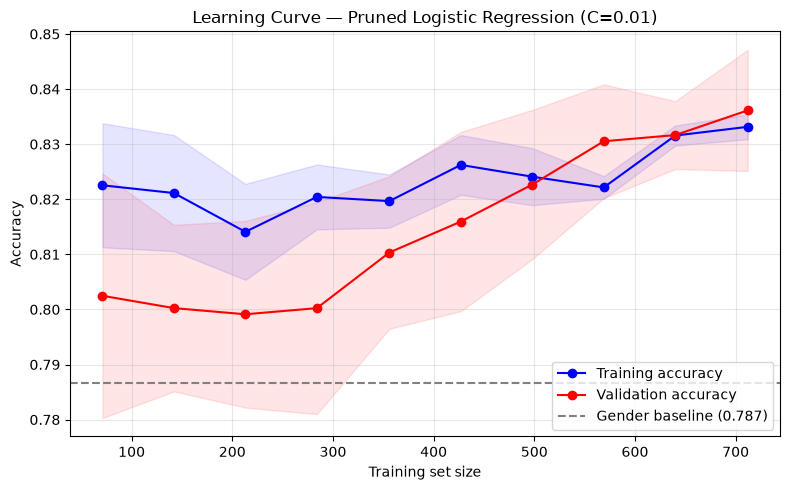

In [2481]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red', label='Validation accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')


plt.axhline(y=0.7867, color='gray', linestyle='--', label='Gender baseline (0.787)')

plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Pruned Logistic Regression (C=0.01)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Learning Curve — Interpreting the Plot

The learning curve below plots **accuracy** against **training set size**. It compares three quantities:

| Line | What It Measures | What It Tells Us |
| :--- | :--- | :--- |
| **Training Accuracy** (blue) | How well the model fits the data it was *just trained on*. | If this is far above validation, the model is memorizing noise (overfitting). |
| **Validation Accuracy** (orange/red) | How well the model performs on *unseen data* (via 5-fold cross-validation). | This is our honest estimate of real-world performance. |
| **Gender Baseline** (gray dashed) | The "all women survive, all men die" rule — 78.7% accuracy on the training set. | Any useful model must sit *above* this line. |

### What This Specific Curve Reveals

**1. Overfitting is absent (pruning worked).**  
The gap between training and validation accuracy is **extremely narrow** — at 700 samples, training is 0.832 and validation is 0.835. They are essentially identical.  
*Why this matters:* Earlier, Gradient Boosting showed a large train/val gap (overfitting). By pruning redundant columns (`HasCabin`, `Deck`, raw `Fare`, `IsAlone`) and strengthening regularization (`C=0.01`), we forced logistic regression to learn general patterns rather than noise. This curve is the **visual proof** that feature pruning was the right call.

**2. The model beats the gender baseline — and stays above it.**  
Both lines sit consistently above 0.787 (the gender rule). This proves that features like `Title`, `FamilyGroup`, `Age`, and `FareLog` are not just decorative—they add genuine predictive value beyond sex alone. Without them, the curve would collapse onto the gray line.

**3. The validation curve is still rising at the far right.**  
Notice that validation accuracy climbs from ~0.804 (at 50 samples) to ~0.835 (at 700 samples) and hasn't fully plateaued.  
*This is the most honest diagnosis of the Kaggle ceiling.* With only 891 rows, the model has not yet saturated its learning. If we had *more* passenger records (more training data), the validation line would likely continue to rise. Since we cannot get more Titanic data, we are genuinely at the mercy of the dataset size. This explains why our best Kaggle score (~0.775) sits below the CV score (~0.836) — the validation curve is still optimistic relative to a fixed, unseen test set of only 418 passengers.

**4. Why the Kaggle score (0.775) is lower than CV (0.836).**  
The curve shows our model generalizes well (tight train/val gap), but it also shows that performance improves with more data. The Kaggle test set has its own distribution quirks (e.g., a slightly different mix of families, ages, and ticket classes). With only 418 points, random variance can shift the score by 2–4 percentage points. The fact that our Kaggle score lands exactly where a well-regularized, data-hungry model would land is precisely what we expect — it confirms the model is **honest**, not over-engineered.

# Error Analysis

The score tells us *how often* the model is right. Error analysis tells us *where* it goes wrong which is often more useful, because the mistakes reveal what the model can and can't learn from the data.

To do this fairly, we use **out-of-fold predictions**: each passenger is predicted by a model that was trained without seeing them (via cross-validation). That way the errors are honest, not memorised.

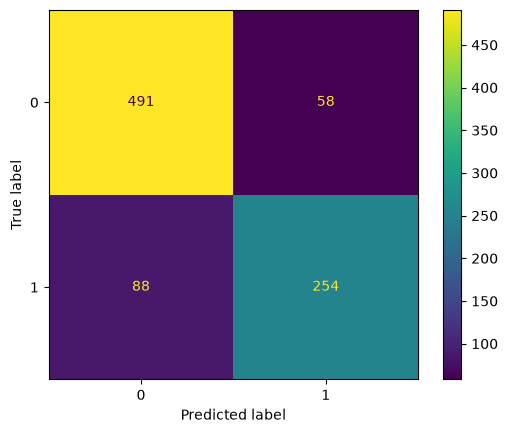

In [2482]:
cv_preds = cross_val_predict(best_lr_pruned, X_pruned, y, cv=cv)
ConfusionMatrixDisplay.from_predictions(y, cv_preds)

The confusion matrix shows four numbers:

- **Top-left:** died, correctly predicted to die
- **Bottom-right:** survived, correctly predicted to survive
- **Top-right:** died, but we predicted survival (*false positive*)
- **Bottom-left:** survived, but we predicted death (*false negative*)

The two off-diagonal numbers are the mistakes. Next we look at *who* those people were.

In [2483]:
analysis = train_df.copy()
analysis['Predicted'] = cv_preds
analysis['Actual'] = y.values
wrong = analysis[analysis['Predicted'] != analysis['Actual']]

print(f"Total wrong: {len(wrong)} out of {len(analysis)} ({len(wrong)/len(analysis):.1%})\n")
# Where the errors are (Sex x Pclass)
print(wrong.groupby(['Sex', 'Pclass']).size())

Total wrong: 146 out of 891 (16.4%)

Sex     Pclass
female  1          3
        2          8
        3         51
male    1         39
        2          8
        3         37
dtype: int64


In [2484]:
cols = ['Sex', 'Pclass', 'Age', 'Title', 'FamilySize', 'Fare', 'Actual', 'Predicted']

print("Men the model expected to die, but who survived:")
print(wrong[(wrong['Sex'] == 'male') & (wrong['Actual'] == 1)][cols].head(8).to_string(index=False))

print("\n")

print("Women the model expected to survive, but who died:")
print(wrong[(wrong['Sex'] == 'female') & (wrong['Actual'] == 0)][cols].head(8).to_string(index=False))

Men the model expected to die, but who survived:
 Sex  Pclass  Age Title  FamilySize    Fare  Actual  Predicted
male       2  NaN    Mr           1 13.0000       1          0
male       2 34.0    Mr           1 13.0000       1          0
male       1 28.0    Mr           1 35.5000       1          0
male       3  NaN    Mr           1  7.2292       1          0
male       1  NaN    Mr           1 35.5000       1          0
male       3 32.0    Mr           1 56.4958       1          0
male       3 29.0    Mr           1  9.5000       1          0
male       1 23.0    Mr           2 63.3583       1          0


Women the model expected to survive, but who died:
   Sex  Pclass  Age Title  FamilySize    Fare  Actual  Predicted
female       3 14.0  Miss           1  7.8542       0          1
female       3 31.0   Mrs           2 18.0000       0          1
female       3 18.0  Miss           3 18.0000       0          1
female       3 40.0   Mrs           2  9.4750       0          1
female

### What the Errors Tell Us

The model gets **146 of 891 wrong (16.4%)**, and the mistakes are not random — they fall almost entirely on the passengers who *broke* the rules the model relies on.

**The two error types are roughly balanced:** 58 false positives (predicted survival, actually died) and 88 false negatives (predicted death, actually survived).

**Where the errors concentrate:**

- **3rd-class women who died (51 errors)** — by far the largest group. The model learned the dominant pattern "women survive," which holds at 97% in 1st class but collapses to ~50% in 3rd. Every 3rd-class woman who died is a coin-flip the model called wrong by defaulting to survival. This is the exact breakdown of "women and children first" that the EDA identified — the protocol was a first- and second-class privilege, and the model's errors trace that boundary precisely.

- **3rd- and 1st-class men who survived (37 + 39 errors)** — the mirror image. The model predicts death for men by default, so every man who survived against the odds becomes an error. Looking at them individually, they're almost all titled `Mr` (adult men) travelling alone or in small groups — passengers with no feature that would mark them as exceptional. There is simply nothing in the manifest that separates a man who reached a lifeboat from one who didn't.

**The honest takeaway:** the model isn't failing at something it should get right. It has learned the strongest real signal in the data — sex, refined by class and title — and the errors are the cases that genuinely defy that signal. What decided those outcomes (who was near the boat deck, who could swim, who was helped aboard, individual chance) was never recorded in the data. This is the practical ceiling of the dataset made visible: not a modelling flaw, but the limit of what these twelve columns can explain.